# Домашнее задание 2 - предобработка признаков, pandas


### О задании

Практическое задание 2 посвящено изучению основных библиотек для анализа данных, а также линейных моделей и методов их обучения. Вы научитесь:
 * применять библиотеки NumPy и Pandas для осуществления желаемых преобразований;
 * подготавливать данные для обучения линейных моделей;
 * обучать линейную, Lasso и Ridge-регрессии при помощи модуля scikit-learn;
 * реализовывать обычный и стохастический градиентные спуски;
 * обучать линейную регрессию для произвольного функционала качества.


### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Кроме того, некоторые из заданий являются опциональными (необязательными), однако за их выполнение можно получить дополнительные баллы, которые позднее будут учитываться при проставлении оценок автоматом по курсу.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце Вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Для сдачи задания получившийся файл \*.ipynb с решением необходимо выложить в свой репозиторий github.

## Библиотеки для анализа данных

### NumPy

Во всех заданиях данного раздела запрещено использовать циклы  и list comprehensions. Под вектором и матрицей в данных заданиях понимается одномерный и двумерный numpy.array соответственно.

In [ ]:
import numpy as np

**1. (0.2 балла)** Реализуйте функцию, возвращающую максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой. Для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответом является 5. Если нулевых элементов нет, функция должна возвращать None.


In [ ]:
def max_element(x):
    if not np.any(x == 0):
        return None
    return np.max(x[1:][x[:-1] == 0])

print(max_element(np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])))

5


**2. (0.2 балла)** Реализуйте функцию, принимающую на вход матрицу и некоторое число и возвращающую ближайший к числу элемент матрицы. Например: для X = np.arange(0,10).reshape((2, 5)) и v = 3.6 ответом будет 4.

In [ ]:
def nearest_value(X, v):
    return X.flat[np.abs(X - v).argmin()]

X = np.arange(0, 10).reshape((2, 5))
v = 3.6
print(nearest_value(X, v))

4


**3. (0.2 балла)** Реализуйте функцию scale(X), которая принимает на вход матрицу и масштабирует каждый ее столбец (вычитает выборочное среднее и делит на стандартное отклонение). Убедитесь, что в функции не будет происходить деления на ноль. Протестируйте на случайной матрице (для её генерации можно использовать, например, функцию [numpy.random.randint](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randint.html)).

In [ ]:
def scale(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)

    #замена нулей
    std[std == 0] = 1

    #Масштабирование
    return (X - mean) / std

X = np.random.randint(0, 10, size=(4, 3))
print("Исходная матрица:\n", X)
print("Масштабированная:\n", scale(X))

Исходная матрица:
 [[2 9 1]
 [2 9 1]
 [7 6 8]
 [8 0 7]]
Масштабированная:
 [[-0.9918366   0.81649658 -0.99413485]
 [-0.9918366   0.81649658 -0.99413485]
 [ 0.81150267  0.          1.14707867]
 [ 1.17217053 -1.63299316  0.84119102]]


**4. (0.2 балла)** Реализуйте функцию, которая для заданной матрицы находит:
 - определитель
 - след
 - наименьший и наибольший элементы
 - норму Фробениуса
 - собственные числа
 - обратную матрицу

Для тестирования сгенерируйте матрицу с элементами из нормального распределения $\mathcal{N}$(10,1)

In [ ]:
def get_stats(A):
    det = np.linalg.det(A)
    trace = np.trace(A)
    min_el = A.min()
    max_el = A.max()
    frob_norm = np.linalg.norm(A, 'fro')
    eigenvalues = np.linalg.eigvals(A)

    try:
        inv = np.linalg.inv(A)               # Обратная матрица
    except np.linalg.LinAlgError:
        inv = None                           #eсли вырождена

    return {
        'Определитель': det,
        'След': trace,
        'min': min_el,
        'max': max_el,
        'Норма Фробениуса': frob_norm,
        'Собств. числа': eigenvalues,
        'Обратная': inv
    }

np.random.seed(42)
A = np.random.normal(10, 1, size=(3, 3))
result = get_stats(A)

for k, v in result.items():
    print(f"{k}:\n{v}\n")

Определитель:
22.40377354921103

След:
29.793086392352947

min:
9.530525614065049

max:
11.579212815507391

Норма Фробениуса:
31.38755975091779

Собств. числа:
[31.30028766+0.j        -0.75360063+0.3845192j -0.75360063-0.3845192j]

Обратная:
[[-0.53917888  0.9222003  -0.34259108]
 [ 0.14553242 -1.03788982  0.9009268 ]
 [ 0.49066089  0.05215424 -0.49669197]]



**5. (0.2 балла)** Повторите 100 раз следующий эксперимент: сгенерируйте две матрицы размера 10×10 из стандартного нормального распределения, перемножьте их (как матрицы) и найдите максимальный элемент. Какое среднее значение по экспериментам у максимальных элементов? 95-процентная квантиль?

In [ ]:
np.random.seed(0)
max_values = []

for exp_num in range(100):
    A = np.random.randn(10, 10)
    B = np.random.randn(10, 10)
    C = A @ B
    max_values.append(np.max(C))

mean_val = np.mean(max_values)
quantile_95 = np.quantile(max_values, 0.95)

print(mean_val, quantile_95)

8.227937605160266 11.260147599088283


**5. (0.2 балла)** Повторите 100 раз следующий эксперимент: сгенерируйте две матрицы размера 10×10 из стандартного нормального распределения, перемножьте их (как матрицы) и найдите максимальный элемент. Какое среднее значение по экспериментам у максимальных элементов? 95-процентная квантиль?

### Pandas

![](https://metrouk2.files.wordpress.com/2015/10/panda.jpg)

#### Ответьте на вопросы о данных по авиарейсам в США за январь-апрель 2008 года.

Данные находятся в приложенном файле `2008.csv`. Их [описание](http://stat-computing.org/dataexpo/2009/the-data.html) приведено ниже:

Airline on-time performance

Have you ever been stuck in an airport because your flight was delayed or cancelled and wondered if you could have predicted it if you'd had more data? This is your chance to find out.

The data
The data set is available for download here.
The data consists of flight arrival and departure details for all commercial flights within the USA, from October 1987 to April 2008. This is a large dataset: there are nearly 120 million records in total, and takes up 1.6 gigabytes of space compressed and 12 gigabytes when uncompressed.

Understanding and preparing the data
In order to answer above questions, we are going to analyze the provided dataset, containing up to 1936758 ### different internal flights in the US for 2008 and their causes for delay, diversion and cancellation

The data comes from the U.S. Department of Transportation’s (DOT) Bureau of Transportation Statistics (BTS). Meta data explanations

This dataset is composed by the following variables:

**Year** 2008 **Month** 1-12 **DayofMonth** 1-31 **DayOfWeek** 1 (Monday) - 7 (Sunday)  
**DepTime** actual departure time (local, hhmm)  
**CRSDepTime** scheduled departure time (local, hhmm)  
**ArrTime** actual arrival time (local, hhmm)  
**CRSArrTime** scheduled arrival time (local, hhmm)  
**UniqueCarrier** unique carrier code  
**FlightNum** flight number  
**TailNum** plane tail number: aircraft registration, unique aircraft identifier  
**ActualElapsedTime** in minutes  
**CRSElapsedTime** in minutes  
**AirTime** in minutes  
**ArrDelay** arrival delay, in minutes: A flight is counted as “on time” if it operated less than 15 minutes later the scheduled time shown in the carriers’ Computerized Reservations Systems (CRS).  
**DepDelay** departure delay, in minutes  
**Origin** origin IATA airport code  
**Dest** destination IATA airport code  
**Distance** in miles  
**TaxiIn** taxi in time, in minutes  
**TaxiOut** taxi out time in minutes  
**Cancelled** *was the flight cancelled  
**CancellationCode** reason for cancellation (A = carrier, B = weather, C = NAS, D = security)  
**Diverted** 1 = yes, 0 = no  
**CarrierDelay** in minutes: Carrier delay is within the control of the air carrier. Examples of occurrences that may determine carrier delay are: aircraft cleaning, aircraft damage, awaiting the arrival of connecting passengers or crew, baggage, bird strike, cargo loading, catering, computer, outage-carrier equipment, crew legality (pilot or attendant rest), damage by hazardous goods, engineering inspection, fueling, handling disabled passengers, late crew, lavatory servicing, maintenance, oversales, potable water servicing, removal of unruly passenger, slow boarding or seating, stowing carry-on baggage, weight and balance delays.  
**WeatherDelay** in minutes: Weather delay is caused by extreme or hazardous weather conditions that are forecasted or manifest themselves on point of departure, enroute, or on point of arrival.  
**NASDelay** in minutes: Delay that is within the control of the National Airspace System (NAS) may include: non-extreme weather conditions, airport operations, heavy traffic volume, air traffic control, etc.  
**SecurityDelay** in minutes: Security delay is caused by evacuation of a terminal or concourse, re-boarding of aircraft because of security breach, inoperative screening equipment and/or long lines in excess of 29 minutes at screening areas.  
**LateAircraftDelay** in minutes: Arrival delay at an airport due to the late arrival of the same aircraft at a previous airport. The ripple effect of an earlier delay at downstream airports is referred to as delay propagation.

In [ ]:
import pandas as pd
%matplotlib inline

**6. (0.3 балла)** Какая из причин отмены рейса (`CancellationCode`) была самой частой? (расшифровки кодов можно найти в описании данных)

In [ ]:
dat = pd.read_csv('2008.csv')

counts = dat['CancellationCode'].value_counts()

most_common = counts.idxmax()
most_common, counts[most_common]

('A', np.int64(563))

**7. (0.3 балла)** Найдите среднее, минимальное и максимальное расстояние, пройденное самолетом.

In [ ]:
dat['Distance'].agg(['mean', 'min', 'max'])

,Distance
mean,724.508257
min,31.000000
max,4962.000000


**8. (0.3 балла)** Не выглядит ли подозрительным минимальное пройденное расстояние? В какие дни и на каких рейсах оно было? Какое расстояние было пройдено этими же рейсами в другие дни?

In [ ]:
min_dist = dat['Distance'].min()

min_flights = dat[dat['Distance'] == min_dist]

print(min_flights[['Year', 'Month', 'DayofMonth', 'Origin', 'Dest', 'FlightNum', 'Distance']], '\n')

# те же рейсы в другие дни
same_flights_other_days = dat[
    (dat['FlightNum'].isin(min_flights['FlightNum'])) &
    (dat['Distance'] != min_dist)
]
print(same_flights_other_days[['Year', 'Month', 'DayofMonth', 'Origin', 'Dest', 'FlightNum', 'Distance']])


       Year  Month  DayofMonth Origin Dest  FlightNum  Distance
1116   2008     12          30    WRG  PSG         65        31
6958   2008     12          26    WRG  PSG         65        31
17349  2008      8          18    PSG  WRG         64        31
27534  2008      3          11    PSG  WRG         64        31
46082  2008      8           9    WRG  PSG         65        31
48112  2008      2          28    PSG  WRG         64        31 

       Year  Month  DayofMonth Origin Dest  FlightNum  Distance
501    2008      3          20    ATL  IAD         64       533
1389   2008      3          13    KTN  SEA         64       680
1517   2008      7          10    SEA  KTN         65       680
2619   2008      5          23    LAS  BOS         64      2381
3869   2008      7           1    WRG  KTN         64        82
...     ...    ...         ...    ...  ...        ...       ...
66529  2008     12          21    KTN  WRG         65        82
67172  2008      3          22    ATL 

**9. (0.3 балла)** Из какого аэропорта было произведено больше всего вылетов? В каком городе он находится?

In [ ]:

dat['Origin'].value_counts().head(1)


,count
Origin,
ATL,4134


**10. (0.3 балла)** Найдите для каждого аэропорта среднее время полета (`AirTime`) по всем вылетевшим из него рейсам. Какой аэропорт имеет наибольшее значение этого показателя?

In [ ]:
avg_airtime = dat.groupby('Origin')['AirTime'].mean()
max_airtime_origin = avg_airtime.idxmax()
max_airtime_origin, avg_airtime[max_airtime_origin]


('SJU', np.float64(205.2))

**11. (0.5 балла)** Найдите аэропорт, у которого наибольшая доля задержанных (`DepDelay > 0`) рейсов. Исключите при этом из рассмотрения аэропорты, из которых было отправлено меньше 1000 рейсов (используйте функцию `filter` после `groupby`).

In [ ]:
delayed = dat.assign(Delayed = dat['DepDelay'] > 0)

result = (
    delayed
    .groupby('Origin')
    .filter(lambda x: len(x) >= 1000) #здесь х-группа по аэропорту
    .groupby('Origin')['Delayed']
    .mean() #считает долю т.к. True = 1 False = 0
)

result.idxmax(), result.max()

('EWR', 0.5111591072714183)

## Линейная регрессия

В этой части мы разберемся с линейной регрессией, способами её обучения и измерением качества ее прогнозов.

Будем рассматривать датасет из предыдущей части задания для предсказания времени задержки отправления рейса в минутах (DepDelay). Отметим, что под задержкой подразумевается не только опоздание рейса относительно планируемого времени вылета, но и отправление до планируемого времени.

### Подготовка данных

**12. (0.5 балла)** Считайте выборку из файла при помощи функции pd.read_csv и ответьте на следующие вопросы:
   - Имеются ли в данных пропущенные значения?
   - Сколько всего пропущенных элементов в таблице "объект-признак"?
   - Сколько объектов имеют хотя бы один пропуск?
   - Сколько признаков имеют хотя бы одно пропущенное значение?

In [3]:
import pandas as pd

dat = pd.read_csv('2008.csv')

# пропуски
has_na = dat.isna().any().any()

# Общее количество пропущенных значений
total_na = dat.isna().sum().sum()

#Количество строк с хотя бы одним пропуском
rows_with_na = dat.isna().any(axis=1).sum()

# количество столбцов с хотя бы одним пропуском
cols_with_na = dat.isna().any().sum()

has_na, total_na, rows_with_na, cols_with_na


(np.True_, np.int64(355215), np.int64(70000), np.int64(16))

Как вы понимаете, также не имеет смысла рассматривать при решении поставленной задачи объекты с пропущенным значением целевой переменной. В связи с этим ответьте на следующие вопросы и выполните соответствующие действия:
- Имеются ли пропущенные значения в целевой переменной?
- Проанализируйте объекты с пропущенными значениями целевой переменной. Чем вызвано это явление? Что их объединяет? Можно ли в связи с этим, на ваш взгляд, исключить какие-то признаки из рассмотрения? Обоснуйте свою точку зрения.

Исключите из выборки объекты **с пропущенным значением целевой переменной и со значением целевой переменной, равным 0**, а также при необходимости исключите признаки в соответствии с вашим ответом на последний вопрос из списка и выделите целевую переменную в отдельный вектор, исключив её из матрицы "объект-признак".

In [4]:
#проверяем пропуски
print(dat['DepDelay'].isna().sum())

# у скольких отменённых рейсовы нет значения
print(dat[dat['DepDelay'].isna()]['Cancelled'].value_counts())

#все строки с пропущенным DepDelay соответствуют отменённым рейсам поэтому такие строки можно удалить

# Удаляем строки, где DepDelay пропущен или равен 0
dat = dat.dropna(subset=['DepDelay'])
dat = dat[dat['DepDelay'] != 0]

# удаляем признаки связанные с отменами
dat = dat.drop(columns=['Cancelled', 'CancellationCode'], errors='ignore')

# Выделяем целевую переменную и матрицу признаков
y = dat['DepDelay']
X = dat.drop(columns=['DepDelay'])

1399
Cancelled
1    1399
Name: count, dtype: int64


**13. (0.5 балла)** Обратите внимание, что признаки DepTime, CRSDepTime, ArrTime, CRSArrTime приведены в формате hhmm, в связи с чем будет не вполне корректно рассматривать их как вещественные.

Преобразуйте каждый признак FeatureName из указанных в пару новых признаков FeatureName\_Hour, FeatureName\_Minute, разделив каждое из значений на часы и минуты. Не забудьте при этом исключить исходный признак из выборки. В случае, если значение признака отсутствует, значения двух новых признаков, его заменяющих, также должны отсутствовать.

Например, признак DepTime необходимо заменить на пару признаков DepTime_Hour, DepTime_Minute. При этом, например, значение 155 исходного признака будет преобразовано в значения 1 и 55 признаков DepTime_Hour, DepTime_Minute соответственно.

In [5]:
for col in ['DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime']:
    dat[col + '_Hour'] = dat[col] // 100
    dat[col + '_Minute'] = dat[col] % 100
    dat = dat.drop(columns=[col])

dat[['DepTime_Hour', 'CRSDepTime_Hour', 'ArrTime_Hour', 'CRSArrTime_Hour']].head()

,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour
0,21.0,20,23.0,23
1,14.0,14,17.0,17
2,11.0,11,15.0,15
3,11.0,11,13.0,13
4,8.0,8,12.0,13


**14. (0.5 балла)** Некоторые из признаков, отличных от целевой переменной, могут оказывать чересчур значимое влияние на прогноз, поскольку по своему смыслу содержат большую долю информации о значении целевой переменной. Изучите описание датасета и исключите признаки, сильно коррелирующие с ответами. Ваш выбор признаков для исключения из выборки обоснуйте. Кроме того, исключите признаки TailNum и Year.

In [6]:
corr = dat.corr(numeric_only=True)['DepDelay'].sort_values(ascending=False)
corr

,DepDelay
DepDelay,1.000000
ArrDelay,0.933526
LateAircraftDelay,0.553806
CarrierDelay,0.532696
WeatherDelay,0.238872
DepTime_Hour,0.203125
NASDelay,0.171591
CRSDepTime_Hour,0.140084
CRSArrTime_Hour,0.135561
TaxiOut,0.101294


In [7]:
to_drop = [
    'ArrDelay', #почти линейно зависим от целевой перем.
    'LateAircraftDelay',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay', # это все части DepDelay, поэтому их присутствие может сильно облегчить обучение модели и она будет давать неправильные прогнозы
    'TailNum',
    'Year'
]

dat = dat.drop(columns=[col for col in to_drop if col in dat.columns])

**15. (1 балл)** Приведем данные к виду, пригодному для обучения линейных моделей. Для этого вещественные признаки надо отмасштабировать, а категориальные — привести к числовому виду. Также надо устранить пропуски в данных.

В первую очередь поймем, зачем необходимо применять масштабирование. Следующие ячейки с кодом построят гистограммы для 3 вещественных признаков выборки.

<Axes: >

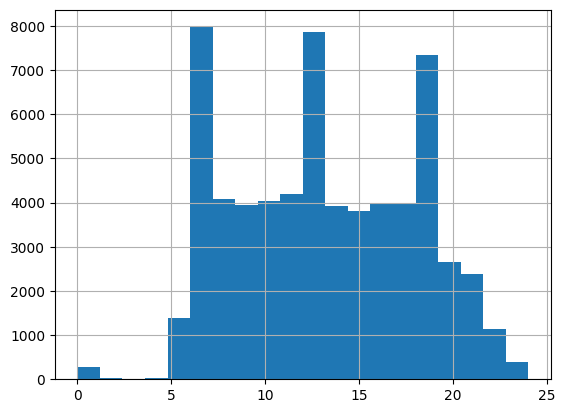

In [ ]:
X['DepTime_Hour'].hist(bins=20)

<Axes: >

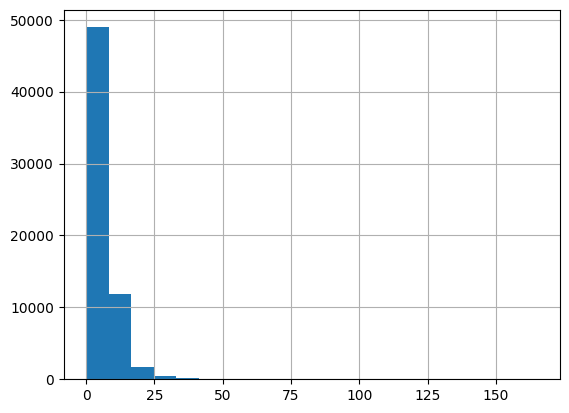

In [ ]:
X['TaxiIn'].hist(bins=20)

<Axes: >

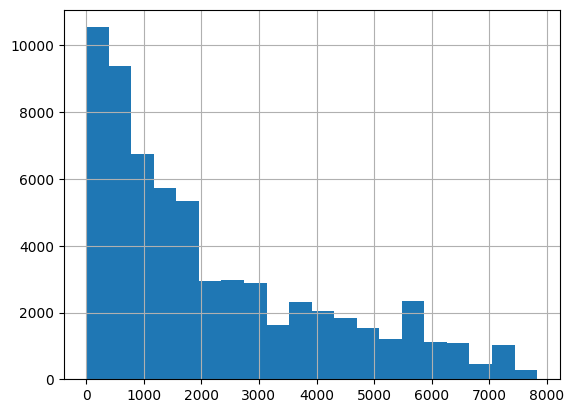

In [ ]:
X['FlightNum'].hist(bins=20)

Какую проблему вы наблюдаете на этих графиках? Как масштабирование поможет её исправить?

Некоторые из признаков в нашем датасете являются категориальными. Типичным подходом к работе с ними является бинарное, или [one-hot-кодирование](https://en.wikipedia.org/wiki/One-hot).

Реализуйте функцию transform_data, которая принимает на вход DataFrame с признаками и выполняет следующие шаги:
1. Замена пропущенных значений на нули для вещественных признаков и на строки 'nan' для категориальных.
2. Масштабирование вещественных признаков с помощью [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).
3. One-hot-кодирование категориальных признаков с помощью [DictVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html) или функции [pd.get_dummies](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html).

Метод должен возвращать преобразованный DataFrame, который должна состоять из масштабированных вещественных признаков и закодированных категориальных (исходные признаки должны быть исключены из выборки).

In [8]:
from sklearn.preprocessing import StandardScaler

def transform_data(df, numeric_cols, categorical_cols):
    df = df.copy()

    # Заполняем пропуски
    df[numeric_cols] = df[numeric_cols].fillna(0)
    df[categorical_cols] = df[categorical_cols].fillna('nan')

    # Масштабируем вещественные признаки
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    # One-hot-кодирование категориальных
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

    return df

Примените функцию transform_data к данным. Сколько признаков получилось после преобразования?

In [9]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_transformed = transform_data(X, numeric_cols, categorical_cols)
print('Было: ', X.shape[1],'Стало: ', X_transformed.shape[1])

Было:  26 Стало:  5743


**16. (0.5 балла)** Разбейте выборку и вектор целевой переменной на обучение и контроль в отношении 70/30 (для этого можно использовать, например, функцию [train_test_split](http://scikit-learn.org/stable/modules/generated/sklearn.cross_validation.train_test_split.html)).

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.3, random_state=42
)

# Проверяем размеры
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(44382, 5743) (19022, 5743) (44382,) (19022,)


### Scikit-learn

<img src = "https://pp.vk.me/c4534/u35727827/93547647/x_d31c4463.jpg">
Теперь, когда мы привели данные к пригодному виду, попробуем решить задачу при помощи метода наименьших квадратов. Напомним, что данный метод заключается в оптимизации функционала $MSE$:

$$MSE(X, y) = \frac{1}{l} \sum_{i=1}^l (<w, x_i> - y_i)^2 \to \min_{w},$$

где $\{ (x_i, y_i ) \}_{i=1}^l$ — обучающая выборка, состоящая из $l$ пар объект-ответ.

Заметим, что решение данной задачи уже реализовано в модуле sklearn в виде класса [LinearRegression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression).

**17. (0.5 балла)** Обучите линейную регрессию на 1000 объектах из обучающей выборки и выведите значения $MSE$ и $R^2$ на этой подвыборке и контрольной выборке (итого 4 различных числа). Проинтерпретируйте полученный результат — насколько качественные прогнозы строит полученная модель? Какие проблемы наблюдаются в модели?

**Подсказка**: изучите значения полученных коэффициентов $w$, сохраненных в атрибуте coef_ объекта LinearRegression.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#первые 1000 объектов выборки
X_sub = X_train[:1000]
y_sub = y_train[:1000]

# Обучаем модель
model = LinearRegression()
model.fit(X_sub, y_sub)

#предсказания
y_train_pred = model.predict(X_sub)
y_test_pred = model.predict(X_test)

# MSE и R2
mse_train = mean_squared_error(y_sub, y_train_pred)
r2_train = r2_score(y_sub, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Train MSE:", mse_train)
print("Train R2:", r2_train)
print("Test MSE:", mse_test)
print("Test R2:", r2_test)

Train MSE: 2.6908440696402226e-26
Train R2: 1.0
Test MSE: 40.95369361141573
Test R2: 0.9693842836081099


Для решения описанных вами в предыдущем пункте проблем используем L1- или L2-регуляризацию, тем самым получив Lasso и Ridge регрессии соответственно и изменив оптимизационную задачу одним из следующих образов:
$$MSE_{L1}(X, y) = \frac{1}{l} \sum_{i=1}^l (<w, x_i> - y_i)^2 + \alpha ||w||_1 \to \min_{w},$$
$$MSE_{L2}(X, y) = \frac{1}{l} \sum_{i=1}^l (<w, x_i> - y_i)^2 + \alpha ||w||_2^2 \to \min_{w},$$

где $\alpha$ — коэффициент регуляризации. Один из способов его подбора заключается в переборе некоторого количества значений и оценке качества на кросс-валидации для каждого из них, после чего выбирается значение, для которого было получено наилучшее качество.

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV

# Lasso
lasso = Lasso(max_iter=10000)
params = {'alpha':[0.01, 0.1, 1, 10, 100]}
grid_lasso = GridSearchCV(lasso, params, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)
print("Лучший alpha Lasso:", grid_lasso.best_params_, "R2:", grid_lasso.best_score_)

# Ridge
ridge = Ridge(max_iter=10000)
grid_ridge = GridSearchCV(ridge, params, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
print("Лучший alpha Ridge:", grid_ridge.best_params_, "R2:", grid_ridge.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.202e+04, tolerance: 4.384e+03
  model = cd_fast.enet_coordinate_descent(


Лучший alpha Lasso: {'alpha': 0.01} R2: 0.9831580977683106
Лучший alpha Ridge: {'alpha': 10} R2: 0.9828114083135396


__18. (1 балл) __ Обучение линейной регрессии.



Обучите линейную регрессию с $L_1$ (Lasso) и $L_2$ (Ridge) регуляризаторами (используйте параметры по умолчанию). Посмотрите, какое количество коэффициентов близко к 0 (степень близости к 0 определите сами из разумных пределов). Постройте график зависимости числа ненулевых коэффициентов от коэффицента регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$). Согласуются ли результаты с вашими ожиданиями?

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+04, tolerance: 5.694e+03
  model = cd_fast.enet_coordinate_descent(


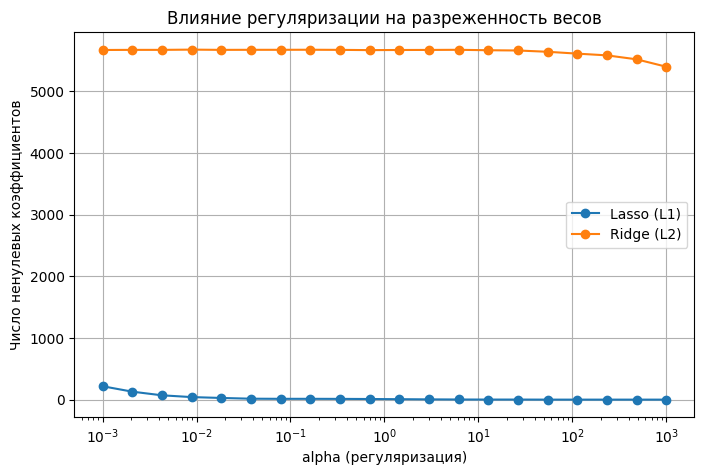

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge

# логарифмическая сетка значений
alphas = np.logspace(-3, 3, 20)

lasso_nonzero = []
ridge_nonzero = []

for a in alphas:
    #Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    # считаем, сколько коэффициентов не близки к нулю
    lasso_nonzero.append(np.sum(np.abs(lasso.coef_) > 1e-3))

     #Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_nonzero.append(np.sum(np.abs(ridge.coef_) > 1e-3))


plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_nonzero, 'o-', label='Lasso (L1)')
plt.plot(alphas, ridge_nonzero, 'o-', label='Ridge (L2)')
plt.xscale('log')
plt.xlabel('alpha (регуляризация)')
plt.ylabel('Число ненулевых коэффициентов')
plt.title('Влияние регуляризации на разреженность весов')
plt.legend()
plt.grid(True)
plt.show()


Посчитайте для Ridge-регрессии следующие метрики: $RMSE$, $MAE$, $R^2$.

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10).fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


RMSE: 5.72645021272693
MAE: 1.5227827383037262
R2: 0.9754855401936606


Подберите на обучающей выборке для Ridge-регрессии коэффициент регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$) для каждой из метрик при помощи кросс-валидации c 5 фолдами на тех же 1000 объектах. Для этого воспользуйтесь GridSearchCV и KFold из sklearn. Постройте графики зависимости фукнции потерь от коэффициента регуляризации. Посчитайте те же метрики снова. Заметно ли изменилось качество?

Для выполнения данного задания вам могут понадобиться реализованные в библиотеке объекты [LassoCV](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html), [RidgeCV](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) и [KFold](http://scikit-learn.org/stable/modules/generated/sklearn.cross_validation.KFold.html).

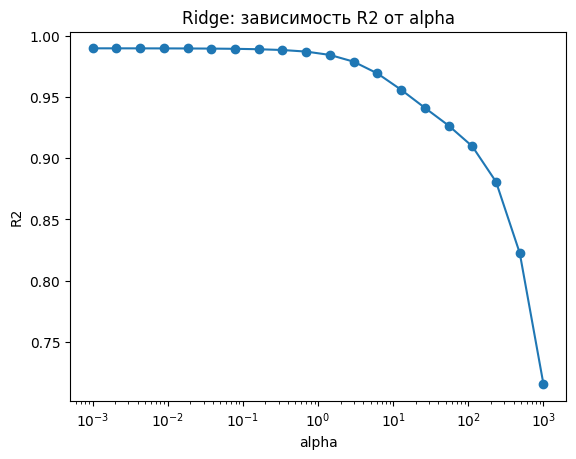

Лучший alpha: 0.001
RMSE: 6.0100646848168715
MAE: 1.6526347633393446
R2: 0.972997147648287


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# сетка значений альфа
alphas = np.logspace(-3, 3, 20)

# грид-серч по Ridge
ridge = Ridge()
grid = GridSearchCV(ridge, {'alpha': alphas}, cv=5, scoring='r2')
grid.fit(X_train[:1000], y_train[:1000])

# график зависимости R2 от alpha
plt.plot(alphas, grid.cv_results_['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R2')
plt.title('Ridge: зависимость R2 от alpha')
plt.show()

# лучший результат
best_alpha = grid.best_params_['alpha']
print("Лучший alpha:", best_alpha)

# проверка на тесте
best_model = Ridge(alpha=best_alpha).fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


__19. (0.5 балла)__ Поиск объектов-выбросов


Как известно, MSE сильно штрафует за большие ошибки на объектах-выбросах. С помощью cross_val_predict сделайте Out-of-Fold предсказания для обучающей выборки. Посчитайте ошибки и посмотрите на их распределение (plt.hist). Что вы видите?

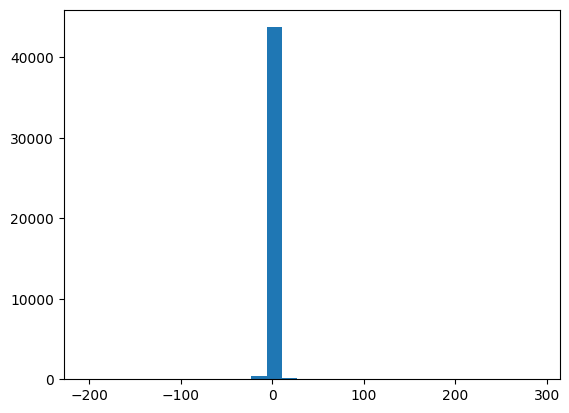

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

pred = cross_val_predict(Ridge(), X_train, y_train, cv=5)
plt.hist(y_train - pred, bins=30)
plt.show()